In [2]:
%pip install opencv-python

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
    --------------------------------------- 0.5/40.2 MB 799.2 kB/s eta 0:00:50
    --------------------------------------- 0.8/40.2 MB 907.1 kB/s eta 0:00:44
    --------------------------------------- 0.8/40.2 MB 907.1 kB/s eta 0:00:44
   - -------------------------------------- 1.0/40.2 MB 786.4 kB/s eta 0:00:50
   - -------------------------------------- 1.3/40.2 MB 828.3 kB/s eta 0:00:47
   - -------------------------------------- 1.6/40.2 MB 864.6 kB/s eta 0:00:45
   - -------------------------------------- 1.8/40.2 MB 907.1 kB/s eta 0:00:43
   -- ------------------------------------- 2.1/40.2 MB 939.6 kB/s eta 0:00:41
   -- ------------------------------------- 2.1/40.2 MB 939.6 kB/s eta 0:00:41
   -- ------------------------------------- 2.1/40.2 MB 939.6 kB/s eta 0:00:41



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


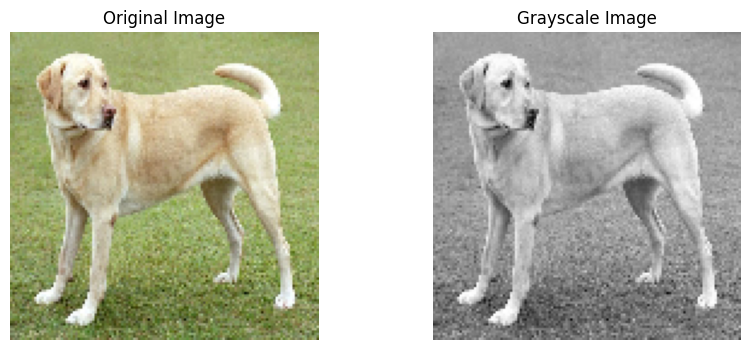

Kernel:
 [[-1. -1. -1.]
 [-1.  8. -1.]
 [-1. -1. -1.]]
Shape after grayscale: (128, 128)
Shape after convolution: (128, 128)
Shape after ReLU: (128, 128)
Shape after pooling: (64, 64)
Shape after flatten: (4096,)


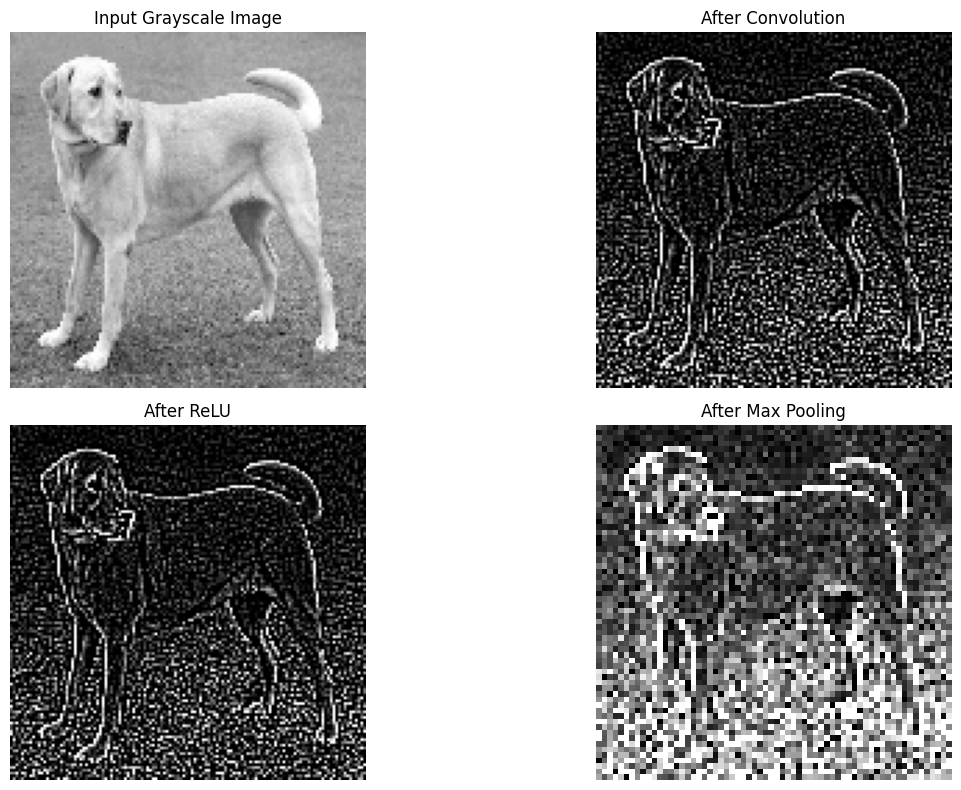

First 20 flattened values:
[76. 65. 40. 12. 60. 46. 15. 27. 50. 12. 43. 39. 34. 17. 51. 24. 22. 23.
 52. 33.]
Input shape for Keras CNN: (1, 128, 128, 1)


c:\Users\Jayshri\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 8)    │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       460,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 462,146 (1.76 MB)

 Trainable params: 462,146 (1.76 MB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Model output probabilities: [[0.46035516 0.5396449 ]]
Predicted class: 1


In [4]:
# Step 1: Import libraries
import numpy as np
import cv2
import matplotlib.pyplot as plt
import urllib.request
import tensorflow as tf
from tensorflow.keras import layers, models

# Step 2: Download a real image from URL
url = "https://storage.googleapis.com/download.tensorflow.org/example_images/YellowLabradorLooking_new.jpg"
urllib.request.urlretrieve(url, "dog.jpg")

# Step 3: Read image using OpenCV
image = cv2.imread("dog.jpg")

# Step 4: Convert BGR to RGB
# OpenCV reads image in BGR format, but matplotlib shows in RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Step 5: Resize image to small size for easy understanding
image_resized = cv2.resize(image_rgb, (128, 128))

# Step 6: Convert image to grayscale
# CNN can work with color or grayscale. For easy explanation, use grayscale.
gray = cv2.cvtColor(image_resized, cv2.COLOR_RGB2GRAY)

# Step 7: Show original and grayscale image
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image_resized)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.show()

# Step 8: Create a simple convolution filter (edge detection filter)
kernel = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=np.float32)

print("Kernel:\n", kernel)

# Step 9: Apply convolution
convolution_output = cv2.filter2D(gray, -1, kernel)

# Step 10: Apply ReLU
# ReLU(x) = max(0, x)
relu_output = np.maximum(0, convolution_output)

# Step 11: Apply Max Pooling manually
# Pool size = 2x2
def max_pooling(feature_map, size=2, stride=2):
    h, w = feature_map.shape
    output_h = (h - size) // stride + 1
    output_w = (w - size) // stride + 1
    pooled = np.zeros((output_h, output_w))

    for i in range(output_h):
        for j in range(output_w):
            region = feature_map[i*stride:i*stride+size, j*stride:j*stride+size]
            pooled[i, j] = np.max(region)

    return pooled

pooled_output = max_pooling(relu_output, size=2, stride=2)

# Step 12: Flatten output
flatten_output = pooled_output.flatten()

print("Shape after grayscale:", gray.shape)
print("Shape after convolution:", convolution_output.shape)
print("Shape after ReLU:", relu_output.shape)
print("Shape after pooling:", pooled_output.shape)
print("Shape after flatten:", flatten_output.shape)

# Step 13: Show all outputs
plt.figure(figsize=(14, 8))

plt.subplot(2, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Input Grayscale Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(convolution_output, cmap="gray")
plt.title("After Convolution")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(relu_output, cmap="gray")
plt.title("After ReLU")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(pooled_output, cmap="gray")
plt.title("After Max Pooling")
plt.axis("off")

plt.tight_layout()
plt.show()

# Step 14: Show first 20 flattened values
print("First 20 flattened values:")
print(flatten_output[:20])

# Step 15: Now prepare the same image for a simple Keras CNN model
# Convert grayscale image to shape (1, 128, 128, 1)
x = gray.astype("float32") / 255.0
x = np.expand_dims(x, axis=-1)   # (128, 128, 1)
x = np.expand_dims(x, axis=0)    # (1, 128, 128, 1)

print("Input shape for Keras CNN:", x.shape)

# Step 16: Build a very simple CNN model
model = models.Sequential([
    layers.Conv2D(8, (3, 3), activation='relu', input_shape=(128, 128, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(16, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(2, activation='softmax')   # example: 2 output classes
])

# Step 17: Show model summary
model.summary()

# Step 18: Pass image through model
output = model.predict(x)

print("Model output probabilities:", output)
print("Predicted class:", np.argmax(output))